In [1]:
%env CUDA_VISIBLE_DEVICES=1
%cd ..

env: CUDA_VISIBLE_DEVICES=1
/home/ai_n_zag@lab.graphicon.ru/tmp/kolobok


In [2]:
import json
from pathlib import Path

import numpy as np
import cv2

from matplotlib import pyplot as plt, colormaps as cm

import torch
from torch import nn
from torch.nn import functional as F
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision.io import read_image
from torchvision.transforms import functional as VF, InterpolationMode

from tqdm import tqdm

from tire_vision.spike_counter.model import get_model

images_dir = Path("data/dataset_crop")
labels_path = Path("data/result.json")

/home/ai_n_zag@lab.graphicon.ru/tmp/kolobok/external/mmengine/mmengine/optim/optimizer/zero_optimizer.py:11: DeprecationWarning: `TorchScript` support for functional optimizers is deprecated and will be removed in a future PyTorch release. Consider using the `torch.compile` optimizer instead.
  from torch.distributed.optim import \


In [3]:
from mmseg.apis import init_model
cfg_path = "/home/ai_n_zag@lab.graphicon.ru/tmp/kolobok/external/mmsegmentation/configs/fastscnn/fast_scnn_8xb4-160k_cityscapes-512x1024.py"
model = init_model(cfg_path)

/home/ai_n_zag@lab.graphicon.ru/tmp/kolobok/external/mmsegmentation/mmseg/models/losses/cross_entropy_loss.py:250: UserWarning: Default ``avg_non_ignore`` is False, if you would like to ignore the certain label and average loss over non-ignore labels, which is the same with PyTorch official cross_entropy, set ``avg_non_ignore=True``.
  warnings.warn(


In [4]:
class Permute(nn.Module):
    def __init__(self, order: list[int]):
        super().__init__()
        self.order = order

    def forward(self, x: torch.Tensor):
        return x.permute(self.order)


class PermuteLayerNorm(nn.Module):
    def __init__(self, num_features: int, *args, **kwargs):
        super().__init__()
        self.norm = nn.Sequential(
            Permute([0, 2, 3, 1]), nn.LayerNorm(num_features), Permute([0, 3, 1, 2])
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.norm(x)


def replace_norm_layers(model: nn.Module):
    for name, module in model.named_children():
        if "Norm" in module.__class__.__name__ and hasattr(module, "num_features"):
            new_norm = PermuteLayerNorm(num_features=module.num_features)
            setattr(model, name, new_norm)

        elif hasattr(module, "named_children"):
            replace_norm_layers(module)


class SegmentationModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = get_model()
        replace_norm_layers(self.model)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        *_, h, w = x.shape
        return VF.resize(self.model(x), [h, w], interpolation=InterpolationMode.BICUBIC)

In [5]:
with open(labels_path, "r") as f:
    labels = json.load(f)

for i in range(len(labels["images"])):
    name = labels["images"][i]["file_name"]
    name = images_dir / name.split("/")[-1]
    labels["images"][i]["file_name"] = name

In [6]:
class SegmentationDataset(Dataset):
    def __init__(self, labels: dict, prune_empty: bool = True):
        self.labels = labels
        for img in labels["images"]:
            assert Path(img["file_name"]).exists()

        images = [None] * len(self.labels["images"])
        annotations = [[] for _ in range(len(self.labels["images"]))]

        for image in labels["images"]:
            images[image["id"]] = image["file_name"]
        
        for annotation in labels["annotations"]:
            annotations[annotation["image_id"]].append({
                "poly": np.array(annotation["segmentation"], dtype=np.int32).reshape(-1, 2),
                "category": annotation["category_id"] + 1
            })

        self.images = images
        self.annotations = annotations

        if prune_empty:
            ids = [i for i in range(len(self.labels["images"])) if annotations[i]]
            self.images = [self.images[i] for i in ids]
            self.annotations = [self.annotations[i] for i in ids]
                

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx: int):
        image = read_image(self.images[idx]) / 255.
        mask = np.zeros(list(image.shape[1:]), dtype=np.uint8)

        for annotation in self.annotations[idx]:
            mask = cv2.fillPoly(mask, [annotation["poly"]], color=annotation["category"])

        return image, torch.tensor(mask)

In [7]:
class SegmentationLoss(nn.Module):
    def __init__(
        self,
        dice_coef: float = 0.4,
        focal_coef: float = 0.6,
        focal_gamma: float = 2,
    ):
        super().__init__()
        self.dice_coef = dice_coef
        self.focal_coef = focal_coef
        self.focal_gamma = focal_gamma

        

    def focal_loss(self, pred: torch.Tensor, targ: torch.Tensor):
        return torch.mean(
            -targ * (1 - pred) ** self.focal_gamma * torch.log(pred)
            - (1 - targ) * pred**self.focal_gamma * torch.log(1 - pred)
        )

    def dice_loss(self, pred: torch.Tensor, targ: torch.Tensor):
        return 1 - torch.mean(pred * targ + 1) / torch.mean(pred + targ + 1)

    def forward(self, pred: torch.Tensor, targ: torch.Tensor):
        # targ_ohe = F.one_hot(targ.long(), num_classes=pred.shape[-3]).permute(0, 3, 1, 2).float()
        # return (
        #     self.dice_coef * self.dice_loss(pred, targ_ohe) 
        #     + self.focal_coef * self.focal_loss(pred, targ_ohe)
        # )

        weights = torch.ones(pred.shape[-3], device=pred.device) * 0.1
        weights[1:] *= 1000
        
        return F.cross_entropy(pred, targ.long(), weight=weights)

In [8]:
dataset = SegmentationDataset(labels)
print(f"total number of images: {len(dataset)}")

train_dataset, val_dataset = random_split(dataset, [0.75, 0.25])
train_loader = DataLoader(train_dataset, batch_size=1, shuffle=True, num_workers=16)
val_loader = DataLoader(val_dataset, batch_size=1, shuffle=False, num_workers=16)

total number of images: 41


In [9]:
def train_fn(
    model: nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader,
    device: str,
    gradient_accumulation_steps: int = 1,
    n_epochs: int = 5,
):
    model.to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=0.1,
        patience=3,
    )
    loss_fn = SegmentationLoss()

    for epoch in range(1, n_epochs + 1):
        model.train()
        running_loss = 0
        accumulated_loss = 0
        train_loop = tqdm(train_loader, desc=f"[{epoch}/{n_epochs}] Train Epoch")

        for i, (x, y) in enumerate(train_loop):
            x = x.to(device)
            y = y.to(device)

            y_hat = F.sigmoid(model(x)).squeeze(1)
            loss = loss_fn(y_hat, y)
            accumulated_loss += loss / gradient_accumulation_steps

            if (i + 1) % gradient_accumulation_steps == 0 or i == len(train_loader) - 1:
                optimizer.zero_grad()
                accumulated_loss.backward()
                optimizer.step()
                accumulated_loss = 0

            running_loss += loss.item()

            train_loop.set_postfix(loss=running_loss / (i + 1))

        model.eval()
        running_loss = 0
        eval_loop = tqdm(val_loader, desc=f"[{epoch}/{n_epochs}] Evaluation Epoch")

        with torch.no_grad():
            for i, (x, y) in enumerate(eval_loop):
                x = x.to(device)
                y = y.to(device)

                y_hat = F.sigmoid(model(x)).squeeze(1)
                loss = loss_fn(y_hat, y)

                running_loss += loss.item()

                eval_loop.set_postfix(loss=running_loss / (i + 1))

        scheduler.step(metrics=running_loss / (i + 1))


In [10]:
model = SegmentationModel()
def get_num_params(model: nn.Module):
    return sum(param.numel() for param in model.parameters())

print(f"number of model parameters: {get_num_params(model)}")

number of model parameters: 14773198


In [11]:
train_fn(
    model,
    train_loader,
    val_loader,
    "cuda",
    gradient_accumulation_steps=1,
    n_epochs=50,
)

[1/50] Train Epoch:   0%|          | 0/31 [00:00<?, ?it/s]

[50/50] Evaluation Epoch: 100%|██████████| 10/10 [00:00<00:00, 11.65it/s, loss=1.65]


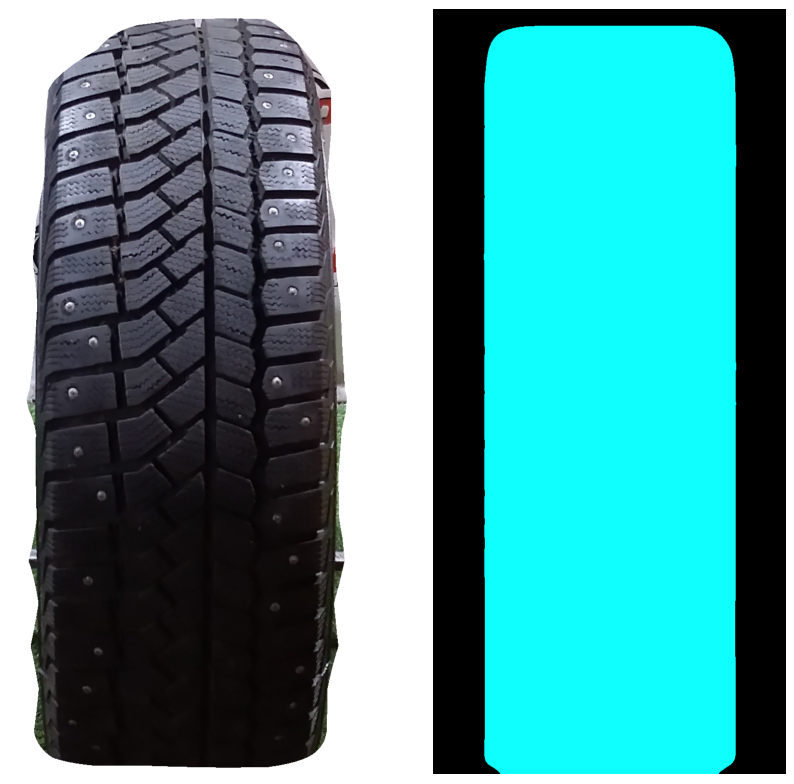

In [12]:
model.eval()
img, gt_mask = val_dataset[5]
pred = model(img[None].to("cuda"))
# pred[:, 1:] *= 5
pred_mask = torch.argmax(pred.cpu().squeeze(), dim=0).numpy()

fig, axes = plt.subplots(ncols=2, figsize=(10, 10))

axes[0].imshow(img.permute(1, 2, 0))
cmap = cm.get_cmap("hsv")
pred_mask = np.where(pred_mask[..., None] != 0, cmap(pred_mask / 6)[..., 1:], 0)
axes[1].imshow(pred_mask)


for ax in axes:
    ax.axis("off")

plt.show()

In [13]:
pred.mean(dim=(0, 2, 3))

tensor([-0.4997, -1.4175, -4.9606, -0.8412,  3.3687, -4.9106], device='cuda:0',
       grad_fn=<MeanBackward1>)